# Machine Learning 1 Coursework

- To be completed by **5pm** on **Thursday 4 December** and uploaded to the [Coursework submission point](https://moodle.bath.ac.uk/mod/assign/view.php?id=1518353) on Moodle.

In [77]:
import numpy as np
import matplotlib.pyplot as plt

def extend_X(Xh):
    """
    Extend all vectors in Xh by 1 in the first component.
    """
    X = np.ones((Xh.size//Xh.shape[-1], Xh.shape[-1]+1))
    X[:, 1:] = Xh
    return X

def softmax(W):
    """
    Compute the softmax function for each row of the input matrix W.
    """
    return np.exp(W) / np.sum(np.exp(W), axis=1, keepdims=True)

def h(Xh, Theta):
    """
    Prediction rule for input data Xh and parameters Theta.
    """
    return softmax(extend_X(Xh) @ Theta)

def loss(Xh, Theta, Y):
    """
    Cross-entropy loss for input data Xh, parameters Theta, and one-hot encoded labels Y.
    """
    return -np.sum(Y * np.log(h(Xh, Theta))) / Xh.shape[0]

def shuffle_split_data(X,Y,Ntest=50):
    """
    Shuffle and split data into training and test sets, with Ntest samples in the test set.
    """
    m = X.shape[0]
    all_range = np.arange(m)  # index array of all data points
    np.random.shuffle(all_range)
    test_range = all_range[:Ntest]  # index array of the test range
    train_range = all_range[Ntest:]  # complement array of the training range
    return X[train_range], Y[train_range], X[test_range], Y[test_range]

def UndersamplingFeatures(Xh):
    """
    Simple undersampling of features by selecting every 100th measurement
    """
    return Xh[:, 700:1700:100]


def OrderClusterLabels(labels, X):
    """
    Order cluster labels by increasing smallest 0th coordinate of x in each cluster.
    labels should contain values between 0 and K-1, where K is the number of clusters.
    """
    K = np.max(labels)+1
    cluster_x0 = [X[(labels==i).nonzero(), 0].min() for i in range(K)]
    reorder = np.arange(K)
    reorder[np.argsort(cluster_x0)] = np.arange(K)
    return reorder[labels]


def test_grad1():
    """ 
    Unit test for grad_loss in Q1
    """
    Xh = np.array([[1]])
    Theta = np.array([[0.5], [1]])
    Y = np.array([[1]])
    assert np.linalg.norm(grad_loss(Xh, Theta, Y))<1e-7, "test_grad1 detected a wrong gradient value"

def test_grad2():
    """ 
    Unit test for grad_loss in Q1
    """
    Xh = np.array([[-1]])
    Theta = np.array([[1,0,0], [1,0,0]])
    Y = np.array([[0.5,0,0.5]])
    G_exact = np.array([[-1/6,1/3,-1/6], [1/6,-1/3,1/6]])
    assert np.linalg.norm(grad_loss(Xh, Theta, Y) - G_exact)<1e-7, "test_grad2 detected a wrong gradient value"

def test_grad3():
    """ 
    Unit test for grad_loss in Q1
    """
    Xh = np.array([[1,0], [0,1]])
    Theta = np.array([[1,0], [0,1], [0,1]])
    Y = np.array([[0,1], [0.25,0.75]])
    G_exact = np.array([[3/8,-3/8], [1/4,-1/4], [1/8,-1/8]])
    assert np.linalg.norm(grad_loss(Xh, Theta, Y) - G_exact)<1e-7, "test_grad3 detected a wrong gradient value"

## Q1 - Gradient Function

Implement a Python function $grad\_loss(Xh, Theta, Y)$ which
takes as input the same arguments as the loss function, and returns a numpy array of the
gradient $G = \Delta{L_{D(\theta)}} ∈ R^{(n+1)×M}$ as defined in,

$$
\nabla L_D(\Theta) = \frac{1}{N} \sum_{i=0}^{N-1} x_i^{\top}\bigl(h_{\Theta}(\hat{x}_i) - y_i\bigr),
\qquad
x_i = [\,1 \;\; \hat{x}_i\,].\hspace{1cm}[8]
$$

In [78]:
def grad_loss(Xh, Theta, Y):
    pred = h(Xh, Theta)
    diff = pred - Y
    X = extend_X(Xh)
    return (X.T @ diff)/X.shape[0]

## Q2 - Adjusted Gradient Descent
Implement a Python function agd($Xtrain$, $Ytrain$, $Xtest$, $Ytest$, $Theta0$, $t$=1, $p$=100, $q$=0.999, $S$=1000, $eps$=1e-8) with inputs: <br>
$\hspace{1cm}$• $Xtrain$, $Ytrain$, $Xtest$, $Ytest$: numpy arrays of the training and test sets. For
example, those can be produced by the function shuffle split data. <br>
$\hspace{1cm}$• $Theta0$: initial guess $\Theta^{0}$ as a numpy array of shape (n+1, M).<br>
$\hspace{1cm}$• $t$: learning rate t > 0 with the default value 1.<br>
$\hspace{1cm}$• $p$: iteration gap $p \in \mathbb{N}$ with the default value 100.<br>
$\hspace{1cm}$• $q$: loss reduction threshold $q > 0$ with the default value 0.999.<br>
$\hspace{1cm}$• $S$: maximal number of iterations $S > 0$ with the default value 1000.<br>
$\hspace{1cm}$• $eps$ = $\epsilon > 0$: safety offset with the default value $10^{−8}$.<br>
    
The function $agd$ should implement Algorithm 1 and return $\Theta^{s∗}$ as a numpy array of shape
(n+1, M), the corresponding iteration number $s∗$, and a numpy array of test losses at all
iterations carried out until the algorithm has stopped, $[L_{D_{test}}{\Theta^{0}}, . . . , L_{D_{test}}{\Theta^{s}}]$.

In [79]:
def agd(X_train, Y_train, X_test, Y_test, Theta0, t=1, p=100, q=0.999, S=1000, eps=1e-8):
    Theta = Theta0.copy()
    loss_current = loss(X_test, Theta, Y_test)
    losses = [loss_current]

    Theta_best = Theta.copy()
    min_loss = loss_current
    best_s = 0
    
    for s in range(1, S+1):
        if s >= p:
            if losses[s-1] > q * losses[s - p]:
                break
        G = grad_loss(X_train, Theta, Y_train)
        v = np.mean(G**2)
        Theta = Theta - t*G/(np.sqrt(v) + eps)
        loss_current = loss(X_test, Theta, Y_test)
        losses.append(loss_current)

        if loss_current < min_loss:
            Theta_best = Theta.copy()
            min_loss = loss_current
            best_s = s
    return Theta_best, best_s, np.array(losses)

# GenAI used to debug and analyse code for problems, identifying a logic error in the early stopping which was fixed.

## Q3)

### a) Classification of X-ray spectra. 

The file CWData.npz contains the following variables: <br>
$\hspace{1cm}$• $Xh$= $\hat{X}$: a 300 × 3959 matrix of noisy and contaminated X-ray absorption spectra of three chromium compounds.<br>
$\hspace{1cm}$• $Y$= $Y$: a 300 × 3 matrix of corresponding labels for those spectra.<br>
$\hspace{1cm}$• $Xhnew$: a 332×3959 matrix of spectra taken at 33×33 pixels of an unknown specimen.<br>
$\hspace{1cm}$• $Energies$: a vector of 3959 energy values at which the absorptions $\hat{x}$ were measured.<br>

Write a Python code to train the classification prediction rule (1) supervised by (Xh, Y), and to predict the unknown labels for Xhnew as follows:<br>
$\hspace{1cm}$(A) Read $Xh$, $Y$, $Xhnew$ and $Energies$ from the file CWData.npz.<br>
$\hspace{1cm}$(B) Apply the function $UndersamplingFeatures$ to $Xh$ and $Xhnew$ and store the returned smaller submatrices as $Zh$ and $Zhnew$, respectively.<br>
$\hspace{1cm}$(C) Split ($Zh$, $Y$) into the training and test sets by using the function shuffle split data
with the default $Ntest=50$.<br>
$\hspace{1cm}$(D) Call the agd function to learn the optimal parameters $\Theta^{s^{∗}}$.<br>
$\hspace{1cm}$(E) Compute and plot the classification image for the prediction $Ynew = h_{\Theta^{s^{∗}}}$ ($Zhnew$).<br>

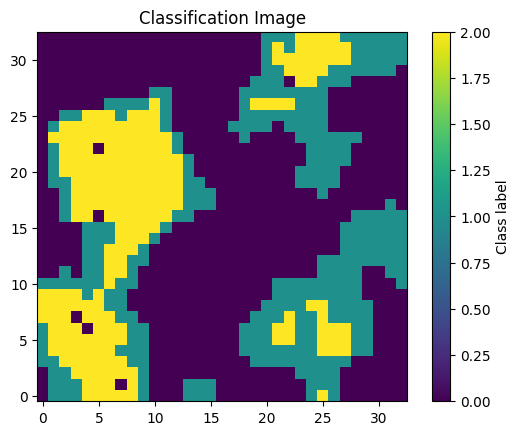

In [87]:
data = np.load('CWData.npz')
Xh = data["Xh"]
Y = data["Y"]
Xhnew = data["Xhnew"]
Energies = data["Energies"]

Zh = UndersamplingFeatures(Xh)
Zhnew = UndersamplingFeatures(Xhnew)

Z_train, Y_train, Z_test, Y_test = shuffle_split_data(Zh, Y)

Theta0 = np.random.randn(Z_test.shape[1] + 1, Y_test.shape[1]) * 0.01 #Random Theta0 to avoid predicting all one class
Theta_agd, best_iter, losses = agd(Z_train, Y_train, Z_test, Y_test, Theta0, t=1/16, S=100000)

Ynew = h(Zhnew, Theta_agd)
c = np.argmax(Ynew, axis=1)
C = c.reshape(33, 33)

# Classification map code generated using GenAI
plt.imshow(C, cmap="viridis", origin='lower')
plt.colorbar(label="Class label")
plt.title("Classification Image")
plt.show()

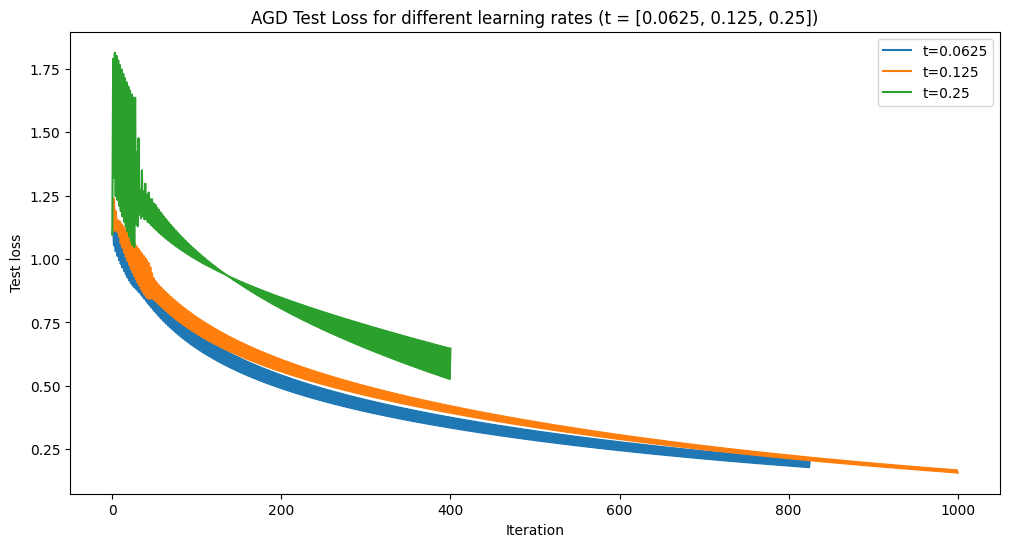

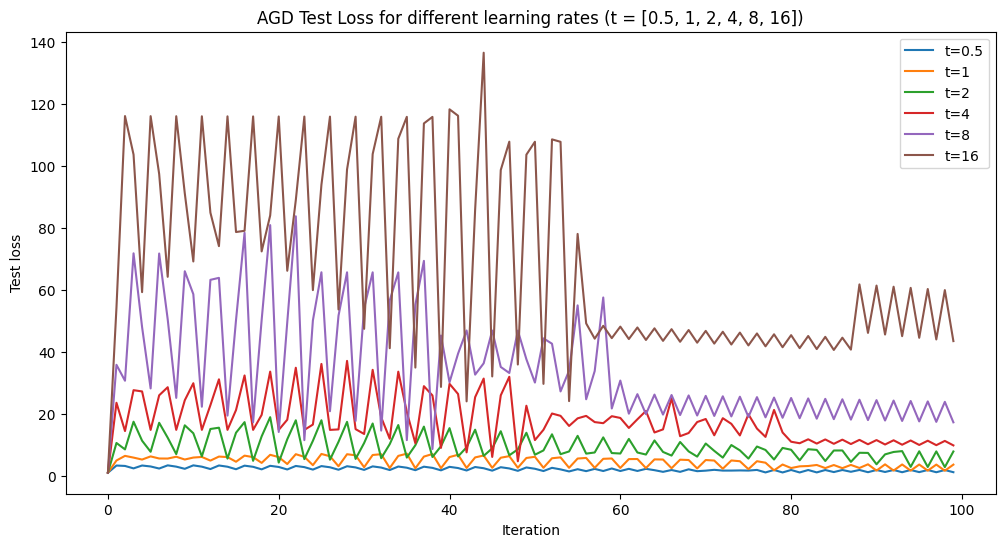

In [88]:
#Determining best value of t

s = 1000
ts = [1/16, 1/8, 1/4, 1/2, 1, 2, 4, 8, 16]
results = {}

for t in ts:
    Theta0 = np.random.randn(Z_test.shape[1] + 1, Y_test.shape[1]) *0.01
    Theta_agd, best_iter, losses = agd(Z_train, Y_train, Z_test, Y_test, Theta0, t=t, S=s)
    results[t] = (Theta_agd, best_iter, losses)


def plot_losses(results, ts):
    plt.figure(figsize=(12, 6))
    for t in ts:
        losses = results[t][2]
        plt.plot(losses, label=f"t={t}")

    plt.legend()
    plt.xlabel("Iteration")
    plt.ylabel("Test loss")
    plt.title(f"AGD Test Loss for different learning rates (t = {ts})")
    plt.show()

plot_losses(results, ts[:3])
plot_losses(results, ts[3:])

# After looking at the graph with various axes limits and removing some values, t=1/16 appears to 
# be the best learning rate in terms of the smoothness of convergence, and the minimisation of loss.

## Q4 - Clustering features.
Implement a Python function $ClusterFeaturesFit(K, Xh, Energies)$ which takes as input the number of clusters $K$, the training data $Xh$, and the vector $Energies$ (horizontal positions in Figure 1). The function should return ordered cluster labels as follows.<br>
$\hspace{1cm}$(A) Concatenate Energies and all training components of Xh into new features,
$X_{clustering} = [Energies\hspace{0.2cm}Xh^{T}] ∈ \mathbb{R}^{3959×301}$.<br>
$\hspace{1cm}$(B) Cluster the rows of $Xclustering$ into $K$ clusters. Make sure you configure the clustering
algorithm of your choice such that the clusters are sufficiently stable.<br>
$\hspace{1cm}$(C) Apply the function $OrderClusterLabels$ to relabel the clusters in the order of increasing energies.<br>

Implement another Python function $ClusterFeaturesPredict(labels, Xh)$ which takes
as input the cluster labels, $labels$, produced by $ClusterFeaturesFit$ and a (possibly different) data matrix $Xh$, and returns a new matrix $Zh$ where the ith column of $Zh$ contains the
average of those columns of $Xh$ where $labels = 0, . . . , K − 1$.


In [89]:
from sklearn.cluster import KMeans

def ClusterFeaturesFit(K, Xh, Energies):
    X_clustering = np.concatenate((Energies.reshape(-1, 1), Xh.T), axis=1)
    kmeans = KMeans(n_clusters=K, n_init=50).fit(X_clustering)
    labels = OrderClusterLabels(kmeans.labels_, Energies.reshape(-1, 1))
    return labels

def ClusterFeaturesPredict(labels, Xh):
    K = np.max(labels)+1
    N = Xh.shape[0]
    Zh = np.zeros((N, K))
    for i in range(K):
        cols = np.where(labels == i)[0]
        if len(cols) != 0:
            Zh[:, i] = Xh[:, cols].mean(axis=1)
    return Zh

## Q5 - Classification with clustering features. 

Using the functions $ClusterFeaturesFit$ and $ClusterFeaturesPredict$ from Question 4, write a Python code similar to Question 3 to classify the X-ray image given by $Xhnew$, but now using the clustering features.

Write a report summarising your findings similarly to Question 3. It can be short (less than
a page), but you need to justify why you’ve made that particular choice (of parameters or
the final output) using numerical results or good and precise arguments at least. Compare
the results to those in Question 3. What other ways to improve the model can you suggest?


In [90]:
data = np.load('CWData.npz')
Xh = data["Xh"]
Y = data["Y"]
Xhnew = data["Xhnew"]
Energies = data["Energies"]

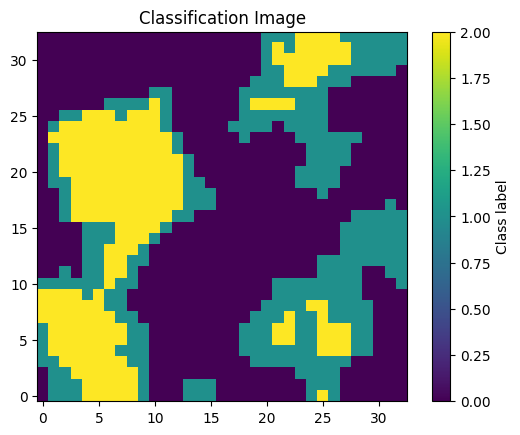

In [ ]:
# K = 16, t = 4 Clustering Classification Model

labels = ClusterFeaturesFit(16, Xh, Energies)
Zh = ClusterFeaturesPredict(labels, Xh)
Zhnew = ClusterFeaturesPredict(labels, Xhnew)
    
Z_train, Y_train, Z_test, Y_test = shuffle_split_data(Zh, Y)
    
Theta0 = np.random.randn(Z_test.shape[1] + 1, Y_test.shape[1]) * 0.01
Theta_agd, best_iter, losses = agd(Z_train, Y_train, Z_test, Y_test, Theta0, t=4, q=0.995, S=100000)

Ynew = h(Zhnew, Theta_agd)
c = np.argmax(Ynew, axis=1)
C = c.reshape(33, 33)

# Classification map code generated using GenAI
plt.imshow(C, cmap="viridis", origin='lower')
plt.colorbar(label="Class label")
plt.title("Classification Image")
plt.show()

In [ ]:
#  Finding best (K, t) combination

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

Ks = np.arange(10, 50)
ts = [1/16, 1/8, 1/4, 1/2, 1, 2, 4, 8, 16]

kf = StratifiedKFold(n_splits=5, shuffle=True)

X_clustering = np.concatenate((Energies.reshape(-1, 1), Xh.T), axis=1)
y_labels = np.argmax(Y, axis=1)
sil_results = np.zeros((len(Ks), 2))

for idx, K in enumerate(Ks):
    labels = ClusterFeaturesFit(K, Xh, Energies)
    sil = silhouette_score(X_clustering, labels)
    sil_results[idx] = [K, sil]

sil_vals = sil_results[:, 1]
sil_threshold = np.percentile(sil_vals, 80) 
K_candidates = sil_results[sil_vals >= sil_threshold, 0].astype(int) # Picks top 20% of Ks

results = []
accuracies = {}

#Cross-validation loop
for K in K_candidates:
    fold_Z_train = []
    fold_Z_test = []
    fold_Y_train = []
    fold_Y_test = []

    # Computing test train sets for each fold
    for train_idx, test_idx in kf.split(Xh, y_labels):
        labels_train = ClusterFeaturesFit(K, Xh[train_idx], Energies)
        Zh_train = ClusterFeaturesPredict(labels_train, Xh[train_idx])
        Zh_test  = ClusterFeaturesPredict(labels_train, Xh[test_idx])

        fold_Z_train.append(Zh_train)
        fold_Z_test.append(Zh_test)
        fold_Y_train.append(Y[train_idx])
        fold_Y_test.append(Y[test_idx])

    for t in ts:
        fold_losses = []
        for Zh_train, Zh_test, Y_train, Y_test in zip(fold_Z_train, fold_Z_test, fold_Y_train, fold_Y_test):
            Theta0 = np.random.randn(Zh_train.shape[1] + 1, Y_train.shape[1]) * 0.01
            Theta_agd, best_iter, losses = agd(Zh_train, Y_train, Zh_test, Y_test, Theta0, p=50, t=t, S=1000)
            fold_losses.append(losses[-1])
        mean_cv_loss = np.mean(fold_losses)
        results.append([K, t, mean_cv_loss])

results = np.array(results)
best_combo_idx = results[:, 2].argmin()
best_K, best_t, best_loss = results[best_combo_idx]

print("Best K:", best_K)
print("Best t:", best_t)
print("CV loss:", best_loss)

Best K: 16.0
Best t: 4.0
CV loss: 1.0240549149421652e-13
